#  Health Risk Tier Prediction Using Artificial Neural Networks

## Project Overview

This project develops and evaluates Artificial Neural Network (ANN) models to predict patient health risk tiers using demographic, lifestyle, and clinical data. The performance of multiple ANN architectures is compared against a Logistic Regression baseline to determine the most effective approach for multiclass health risk classification.

The project also explores feature preprocessing, hyperparameter tuning, regularization techniques, and model evaluation to improve predictive performance and generalization. The best-performing ANN model achieved an accuracy of **80.83%**, outperforming the Logistic Regression baseline.

**Technologies:** Python, TensorFlow/Keras, Scikit-learn, Pandas, NumPy, Matplotlib

## Business Problem

Healthcare providers need reliable methods to identify patients at different health risk levels. Early prediction can support better resource allocation and improve patient care. This project investigates whether Artificial Neural Networks can improve health risk classification compared to a traditional Logistic Regression model.


## Data Preparation

This section explores the dataset and describes the preprocessing steps used before model training.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    learning_curve
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## Load Dataset

In [16]:
df = pd.read_excel("Health_Risk_Tiers_v2.xlsx")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (600, 11)


,patient_id,age,bmi,blood_pressure,glucose_level,physical_activity,sleep_hours,stress_level,cholesterol,family_history,risk_tier
0,1,63,34.1,126,89,Medium,6.8,2,281.0,Yes,2
1,2,23,28.9,127,160,Low,5.3,3,NaN,No,1
2,3,39,18.8,144,171,Medium,7.1,2,224.0,Yes,1
3,4,51,28.5,134,91,High,6.3,8,169.0,No,0
4,5,62,24.6,173,112,High,4.2,5,225.0,Yes,1


## Dataset Exploration

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         600 non-null    int64  
 1   age                600 non-null    int64  
 2   bmi                600 non-null    float64
 3   blood_pressure     600 non-null    int64  
 4   glucose_level      600 non-null    int64  
 5   physical_activity  600 non-null    object 
 6   sleep_hours        600 non-null    float64
 7   stress_level       600 non-null    int64  
 8   cholesterol        561 non-null    float64
 9   family_history     600 non-null    object 
 10  risk_tier          600 non-null    int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 51.7+ KB


In [18]:
df.describe()

,patient_id,age,bmi,blood_pressure,glucose_level,sleep_hours,stress_level,cholesterol,risk_tier
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,561.000000,600.000000
mean,300.500000,48.838333,29.004333,139.631667,136.353333,6.587000,5.705000,225.465241,1.386667
std,173.349358,17.387142,6.367867,24.208940,39.089621,1.398126,2.838674,43.918382,0.686494
min,1.000000,20.000000,18.000000,100.000000,70.000000,4.000000,1.000000,151.000000,0.000000
25%,150.750000,34.000000,23.500000,118.000000,101.000000,5.400000,3.000000,187.000000,1.000000
50%,300.500000,47.000000,29.200000,139.000000,137.000000,6.700000,6.000000,225.000000,2.000000
75%,450.250000,63.000000,34.400000,161.000000,172.000000,7.800000,8.000000,261.000000,2.000000
max,600.000000,80.000000,40.000000,180.000000,200.000000,9.000000,10.000000,300.000000,2.000000


In [19]:
df.isnull().sum()

patient_id            0
age                   0
bmi                   0
blood_pressure        0
glucose_level         0
physical_activity     0
sleep_hours           0
stress_level          0
cholesterol          39
family_history        0
risk_tier             0
dtype: int64

In [20]:
df['risk_tier'].value_counts()

risk_tier
2    302
1    228
0     70
Name: count, dtype: int64

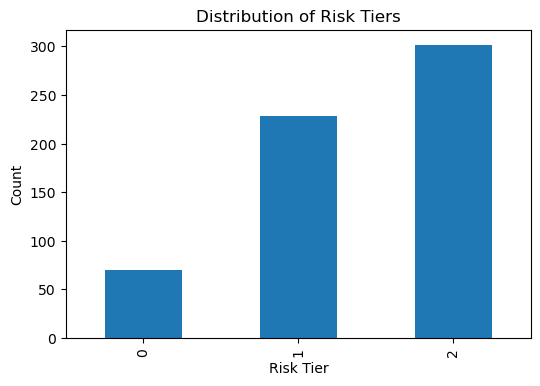

In [21]:
plt.figure(figsize=(6,4))

df['risk_tier'].value_counts().sort_index().plot(kind='bar')

plt.title('Distribution of Risk Tiers')
plt.xlabel('Risk Tier')
plt.ylabel('Count')

plt.show()

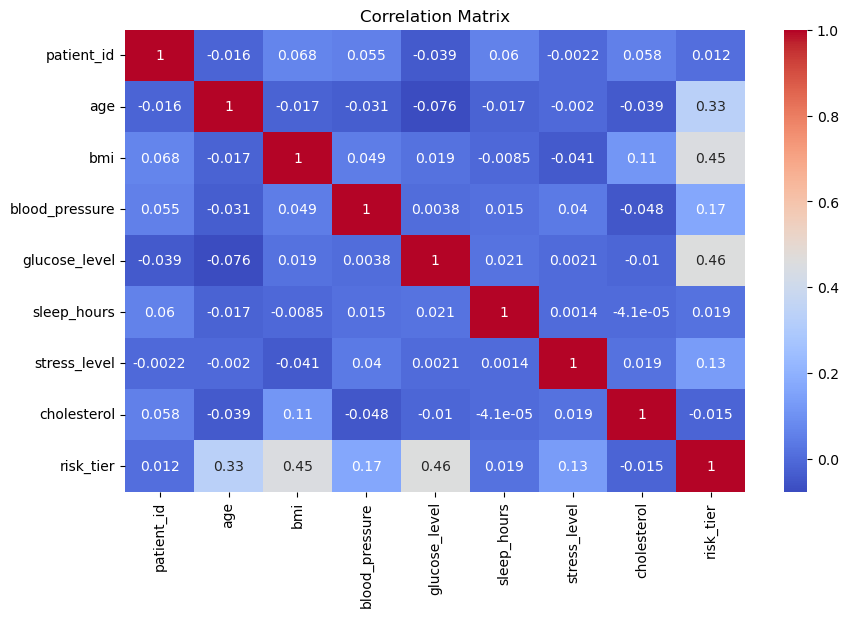

In [22]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

### Observations

- The dataset contains 600 observations.
- The target variable consists of three classes.
- The dataset contains missing values.
- Class imbalance is present, with Risk Tier 2 being the majority class.

## Data Preparation

In [23]:
df = df.drop('patient_id', axis=1)

X = df.drop('risk_tier', axis=1)
y = df['risk_tier']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (600, 9)
Target Shape: (600,)


In [24]:
numerical_cols = X.select_dtypes(include=['int64','float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

print(numerical_cols)
print(categorical_cols)

Index(['age', 'bmi', 'blood_pressure', 'glucose_level', 'sleep_hours',
       'stress_level', 'cholesterol'],
      dtype='object')
Index(['physical_activity', 'family_history'], dtype='object')


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (480, 9)
Testing Set: (120, 9)


## Feature Preprocessing

In [26]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [27]:
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

In [28]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed Training Shape:", X_train_processed.shape)
print("Processed Testing Shape:", X_test_processed.shape)

Processed Training Shape: (480, 12)
Processed Testing Shape: (120, 12)


### Preprocessing Justification

Missing values in numerical variables were handled using median imputation because the median is less sensitive to outliers than the mean. Missing values in categorical variables were replaced using the most frequent category to preserve the existing distribution of observations.

Numerical features were standardized using StandardScaler. Feature scaling is particularly important for Artificial Neural Networks because variables measured on different scales can negatively affect the learning process and convergence of the optimization algorithm.

Categorical variables were transformed using One-Hot Encoding, allowing non-numeric categories to be represented in a numerical format suitable for machine learning models while avoiding the introduction of artificial ordinal relationships.

Together, these preprocessing steps improve data quality, support efficient model training, and promote fair comparison between the ANN and Logistic Regression models.

# Baseline Model – Logistic Regression

In [29]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_processed, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [30]:
y_pred_lr = lr_model.predict(X_test_processed)

In [31]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:",
      round(lr_accuracy, 4))

Logistic Regression Accuracy: 0.7167


In [32]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.58      0.50      0.54        14
           1       0.64      0.61      0.62        46
           2       0.80      0.85      0.82        60

    accuracy                           0.72       120
   macro avg       0.67      0.65      0.66       120
weighted avg       0.71      0.72      0.71       120



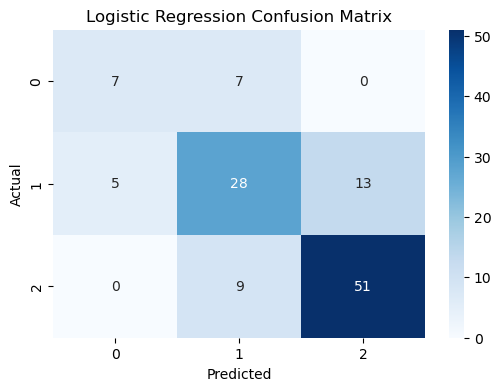

In [33]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## Model Development

### Architecture Justification

The first ANN configuration was designed as a relatively simple neural network consisting of a single hidden layer with 16 neurons. A ReLU activation function was selected because it is computationally efficient and helps mitigate vanishing gradient problems. The Adam optimizer was chosen due to its strong performance and ability to adapt learning rates during training. This configuration serves as a baseline ANN model for comparison with more complex architectures.

In [34]:
ann_model_1 = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42
)

ann_model_1.fit(X_train_processed, y_train)

c:\Users\kadih\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(16,), max_iter=500, random_state=42)

In [35]:
y_pred_ann1 = ann_model_1.predict(X_test_processed)

ann1_accuracy = accuracy_score(y_test, y_pred_ann1)

print("ANN Configuration 1 Accuracy:",
      round(ann1_accuracy, 4))

print(classification_report(y_test, y_pred_ann1))

ANN Configuration 1 Accuracy: 0.775
              precision    recall  f1-score   support

           0       0.54      0.50      0.52        14
           1       0.72      0.67      0.70        46
           2       0.86      0.92      0.89        60

    accuracy                           0.78       120
   macro avg       0.71      0.70      0.70       120
weighted avg       0.77      0.78      0.77       120



### Performance Interpretation

ANN Configuration 1 achieved an accuracy of 77.50%, outperforming the Logistic Regression baseline model, which achieved an accuracy of 71.67%.

The results suggest that the neural network was able to capture nonlinear relationships within the dataset that were not fully represented by the baseline model. Performance was strongest for Risk Tier 2, while lower precision and recall values were observed for Risk Tier 0, likely due to the smaller number of observations within this class.

Although the model demonstrated improved predictive performance, there remained opportunities for further improvement. Consequently, a more complex ANN architecture was explored in the next phase of the analysis.

## Model Optimization

### Hyperparameter Modification

The second ANN configuration increases model complexity by introducing two hidden layers containing 32 and 16 neurons respectively. This modification was implemented to evaluate whether a deeper network could learn more complex relationships within the dataset.

The learning rate was increased from 0.001 to 0.01 to allow the model to update weights more aggressively during training. These changes were expected to improve the model's ability to capture underlying patterns within the data while maintaining reasonable training efficiency.

Comparing this configuration with ANN Configuration 1 allows the impact of architectural and hyperparameter changes to be assessed.

In [36]:
ann_model_2 = MLPClassifier(
    hidden_layer_sizes=(32,16),
    activation='relu',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=500,
    random_state=42
)

ann_model_2.fit(X_train_processed, y_train)

MLPClassifier(hidden_layer_sizes=(32, 16), learning_rate_init=0.01,
              max_iter=500, random_state=42)

In [37]:
y_pred_ann2 = ann_model_2.predict(X_test_processed)

ann2_accuracy = accuracy_score(y_test, y_pred_ann2)

print("ANN Configuration 2 Accuracy:",
      round(ann2_accuracy, 4))

print(classification_report(y_test, y_pred_ann2))

ANN Configuration 2 Accuracy: 0.8083
              precision    recall  f1-score   support

           0       0.65      0.79      0.71        14
           1       0.78      0.70      0.74        46
           2       0.87      0.90      0.89        60

    accuracy                           0.81       120
   macro avg       0.77      0.79      0.78       120
weighted avg       0.81      0.81      0.81       120



### Performance Interpretation

ANN Configuration 2 achieved an accuracy of 80.83%, representing an improvement over both Logistic Regression (71.67%) and ANN Configuration 1 (77.50%).

The deeper architecture and increased learning rate enabled the model to learn more complex patterns within the dataset, resulting in stronger overall classification performance. These findings suggest that increasing network capacity provided additional predictive benefit for this healthcare risk classification problem.

# Regularization & Generalization

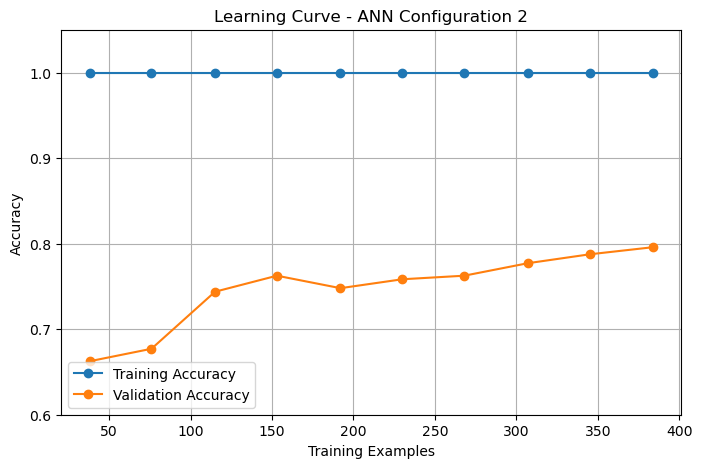

In [38]:
train_sizes, train_scores, val_scores = learning_curve(
    ann_model_2,
    X_train_processed,
    y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    train_sizes,
    val_mean,
    marker='o',
    label='Validation Accuracy'
)

plt.ylim(0.60, 1.05)

plt.title('Learning Curve - ANN Configuration 2')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

### Learning Curve Interpretation

The learning curve indicates that training accuracy remained close to 100% across all training set sizes, while validation accuracy increased gradually as more training examples became available.

The persistent gap between training and validation performance suggests moderate overfitting, as the model performs substantially better on training data than on unseen validation data. However, the validation curve continues to improve with additional training examples, indicating that the model maintains reasonable generalization capability.

Overall, ANN Configuration 2 demonstrates strong predictive performance while exhibiting manageable levels of overfitting.

In [39]:
# Regularized ANN using L2 penalty

mlp_regularized = MLPClassifier(
    hidden_layer_sizes=(32,16),
    activation='relu',
    solver='adam',
    learning_rate_init=0.01,   
    alpha=0.001,               
    max_iter=500,
    random_state=42
)

mlp_regularized.fit(X_train_processed, y_train)

y_pred_reg = mlp_regularized.predict(X_test_processed)

reg_accuracy = accuracy_score(y_test, y_pred_reg)

print("Regularized ANN Accuracy:", reg_accuracy)

Regularized ANN Accuracy: 0.8166666666666667


### Regularization Results

This model achieved an accuracy of 81.67%, compared to 80.83% for ANN Configuration 2. Although the improvement was small, it indicates that regularization had a limited effect on predictive performance while helping to control model complexity.

# Error Analysis

### Evaluation Metrics Justification

Several evaluation metrics were used to assess model performance. Accuracy provides an overall measure of correct predictions across all risk tiers. However, accuracy alone may not fully capture model effectiveness when individual classes are considered.

Therefore, precision, recall, and F1-score were also evaluated. Precision measures how many predicted cases for a class were actually correct, while recall measures how well the model identifies all instances of a class. The F1-score combines precision and recall into a single metric, making it particularly useful for evaluating balanced classification performance across multiple risk tiers.

Together, these metrics provide a more comprehensive assessment of model reliability than accuracy alone.

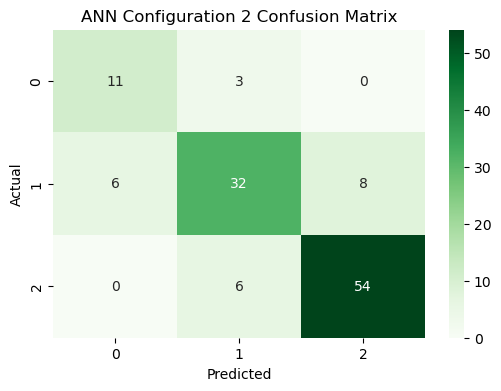

In [40]:
cm_ann2 = confusion_matrix(y_test, y_pred_ann2)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_ann2,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('ANN Configuration 2 Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Error Analysis

The confusion matrix reveals that the model performs best on Risk Tier 2, which achieved the highest number of correct classifications. Most classification errors occurred between Risk Tier 1 and Risk Tier 2, suggesting that these categories share similar characteristics.

Risk Tier 0 experienced the fewest observations and consequently showed lower classification performance. This finding is consistent with the class imbalance observed during exploratory analysis.

Overall, the model demonstrates strong reliability but remains more prone to errors when predicting minority classes.

# Model Comparison

The performance of Logistic Regression and the two ANN configurations were compared using classification accuracy.

In [41]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'ANN Configuration 1',
        'ANN Configuration 2'
    ],
    'Accuracy': [
        lr_accuracy,
        ann1_accuracy,
        ann2_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.716667
1,ANN Configuration 1,0.775000
2,ANN Configuration 2,0.808333


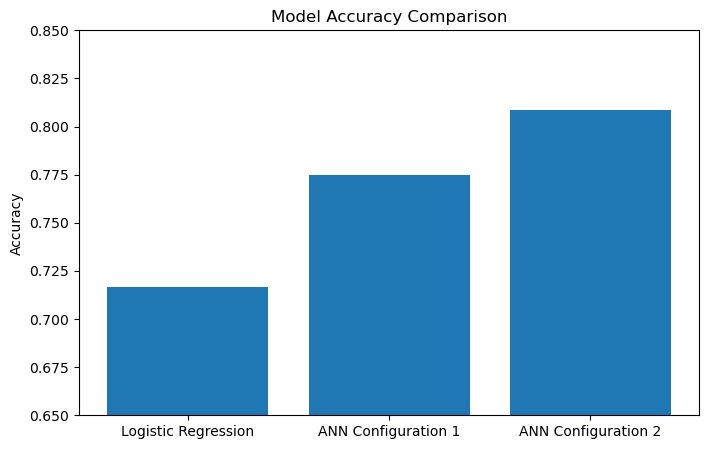

In [42]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison['Model'],
    comparison['Accuracy']
)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.65, 0.85)

plt.show()

### Model Comparison Interpretation

Both ANN configurations outperformed the Logistic Regression baseline model. ANN Configuration 1 improved accuracy from 71.67% to 77.50%, while ANN Configuration 2 achieved the highest accuracy of 80.83%.

These results suggest that the dataset contains nonlinear relationships that are more effectively captured by neural networks. Increasing network complexity further improved predictive performance, supporting the value of ANN architectures for this classification problem.

## Review of Initial Expectations

The initial expectation was that Artificial Neural Networks would outperform Logistic Regression due to their ability to learn nonlinear relationships among patient characteristics.

This hypothesis was supported. Both ANN configurations achieved higher classification accuracy than the Logistic Regression baseline. ANN Configuration 2 achieved the strongest performance (80.83%) and demonstrated the value of increased network complexity.

The expectation that ANN models might experience overfitting was also supported. Learning curve analysis revealed a noticeable gap between training and validation accuracy, although validation performance remained stable and continued to improve with additional training examples.

## Conclusion

This study evaluated the effectiveness of Artificial Neural Networks for predicting patient health risk tiers using the Health_Risk_Tiers_v2 dataset.

A Logistic Regression baseline achieved an accuracy of 71.67%. ANN Configuration 1 improved performance to 77.50%, while ANN Configuration 2 achieved the highest accuracy of 80.83%.

Learning curve analysis indicated moderate overfitting, with training accuracy remaining close to 100% while validation accuracy stabilized near 80%. Despite this gap, validation performance improved as additional training examples were introduced, indicating acceptable generalization capability.

Overall, the findings demonstrate that Artificial Neural Networks are more effective than Logistic Regression for this classification task. ANN Configuration 2 was selected as the preferred model because it achieved the highest predictive performance while maintaining reasonable generalization to unseen data.